Original dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Explained variance ratio: [0.72962445 0.22850762]
Total variance explained: 95.81%
Principal components shape: (150, 2)


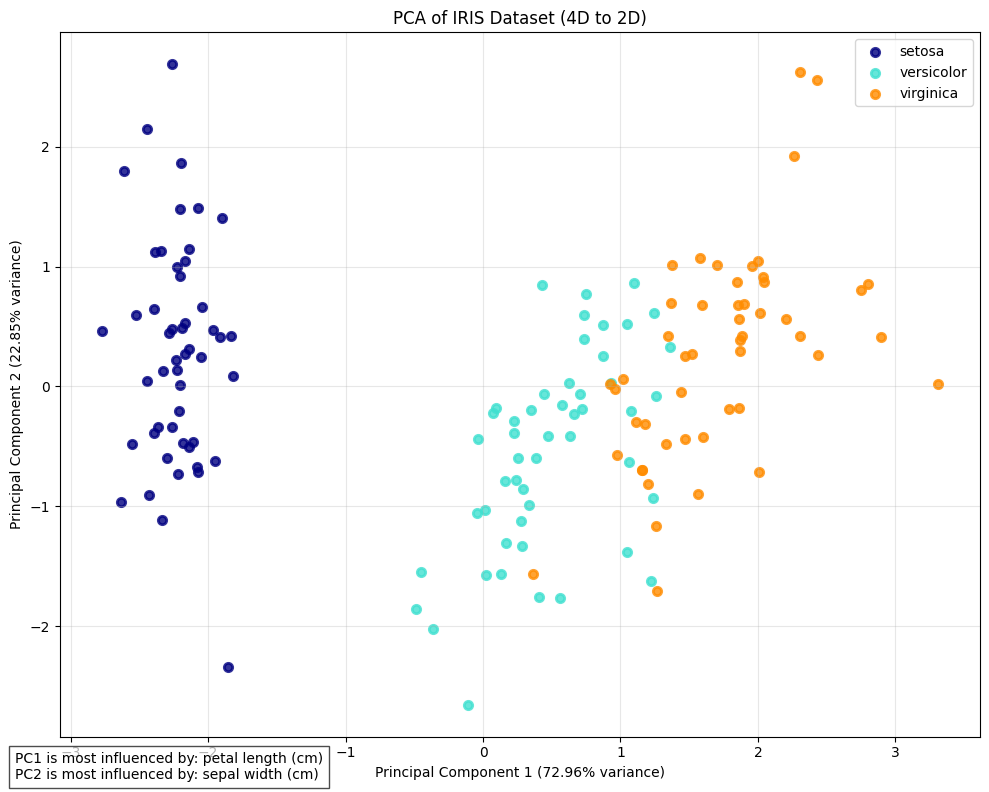


Principal Components Analysis Details:
Component loadings (feature contributions):
PC1: sepal length (cm): 0.521, sepal width (cm): -0.269, petal length (cm): 0.580, petal width (cm): 0.565, 
PC2: sepal length (cm): 0.377, sepal width (cm): 0.923, petal length (cm): 0.024, petal width (cm): 0.067, 

The two principal components explain 95.81% of the total variance.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target
target_names = iris.target_names

print("Original dataset shape:", X.shape)
print("Features:", iris.feature_names)
print("Target classes:", target_names)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(
    "Total variance explained: {:.2f}%".format(
        sum(pca.explained_variance_ratio_) * 100
    )
)
print("Principal components shape:", X_pca.shape)

# Create DataFrame
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PC1', 'PC2']
)

pca_df['species'] = y

pca_df['species_name'] = pca_df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Plot PCA results
plt.figure(figsize=(10, 8))

colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(
    colors,
    [0, 1, 2],
    target_names
):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        color=color,
        alpha=0.8,
        lw=lw,
        label=target_name
    )

plt.legend(
    loc='best',
    shadow=False,
    scatterpoints=1
)

plt.title('PCA of IRIS Dataset (4D to 2D)')

plt.xlabel(
    'Principal Component 1 ({:.2f}% variance)'.format(
        pca.explained_variance_ratio_[0] * 100
    )
)

plt.ylabel(
    'Principal Component 2 ({:.2f}% variance)'.format(
        pca.explained_variance_ratio_[1] * 100
    )
)

# Information about feature contributions
plt.figtext(
    0.02,
    0.02,
    "PC1 is most influenced by: {}\n"
    "PC2 is most influenced by: {}".format(
        iris.feature_names[
            np.argmax(abs(pca.components_[0]))
        ],
        iris.feature_names[
            np.argmax(abs(pca.components_[1]))
        ]
    ),
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print PCA details
print("\nPrincipal Components Analysis Details:")
print("Component loadings (feature contributions):")

for i, component in enumerate(pca.components_):
    print(f"PC{i+1}:", end=" ")

    for j, weight in enumerate(component):
        print(
            f"{iris.feature_names[j]}: {weight:.3f}",
            end=", "
        )

    print()

print(
    "\nThe two principal components explain {:.2f}% "
    "of the total variance.".format(
        sum(pca.explained_variance_ratio_) * 100
    )
)